In [3]:
ls

sample_data/


In [11]:
# pull changes
!git pull

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 942 bytes | 942.00 KiB/s, done.
From https://github.com/Belaleatsbanana/dl
   bfebb6e..04d293a  master     -> origin/master
Updating bfebb6e..04d293a
Fast-forward
 AS_MLP/AS_MLP.py |  8 ++++----
 AS_MLP/config.py | 26 +++++++++++++-------------
 models.py        | 10 +++++-----
 3 files changed, 22 insertions(+), 22 deletions(-)


In [1]:
# skip this cell if you already downloaded the data
!git clone https://github.com/Belaleatsbanana/dl.git
%cd dl
!python get_data.py

Cloning into 'dl'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (251/251), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 251 (delta 116), reused 194 (delta 59), pack-reused 0 (from 0)
Receiving objects: 100% (251/251), 2.47 MiB | 42.22 MiB/s, done.
Resolving deltas: 100% (116/116), done.
/content/dl
Loading dataset from Hugging Face...
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ethz/food101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
README.md: 16.4kB [00:00, 11.3MB/s]
data/train-00000-of-00008.parquet: 100% 490M/490M [00:02<00:00, 173MB/s] 
data/train-00001-of-00008.parquet: 100% 464M/464M [00:02<00:00, 210MB/s] 
data/train-00002-of-00008.parquet: 100% 472M/472M [00:02<00:00, 168MB/s] 
data/train-00003-of-00008.parquet: 100% 464M/

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from torchvision import transforms
import os

def load_model_and_infer(model_name):
    """
    Load a trained model and perform inference on a small validation sample
    
    Args:
        model_name: Name of the model (e.g., 'resnext50_local')
    """
    print(f"\n{'='*60}")
    print(f"Performing inference for {model_name}")
    print(f"{'='*60}\n")
    
    # Import necessary modules
    from models import build_model, get_model_config
    from config import Config
    
    # Load model config
    model_config_data = get_model_config(model_name)
    config = Config(model_config_data)
    
    # Build and load model
    model = build_model(config)
    model.cuda()
    
    # Load saved model weights
    model_path = os.path.join(config.OUTPUT, f'{model_name}.pth')
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at {model_path}")
        return
    
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Loaded model from {model_path}")
    print(f"Model accuracy: {checkpoint['max_accuracy']:.2f}%\n")
    
    # Define class names
    class_names = ['beef_tartare', 'chicken_wings', 'panna_cotta', 'risotto', 'spaghetti_carbonara']
    
    # Define transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Load a small sample from validation set (2 images per class = 10 images total)
    val_dir = './food_subset/val'
    results = []
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(val_dir, class_name)
        images = sorted(os.listdir(class_dir))[:2]  # Take first 2 images from each class
        
        for img_name in images:
            img_path = os.path.join(class_dir, img_name)
            image = Image.open(img_path).convert('RGB')
            
            # Transform and add batch dimension
            img_tensor = transform(image).unsqueeze(0).cuda()
            
            # Perform inference
            with torch.no_grad():
                output = model(img_tensor)
                probabilities = F.softmax(output, dim=1)
                predicted_idx = torch.argmax(probabilities, dim=1).item()
                confidence = probabilities[0][predicted_idx].item()
            
            predicted_class = class_names[predicted_idx]
            is_correct = predicted_idx == class_idx
            
            results.append({
                'image': img_name,
                'true_class': class_name,
                'predicted_class': predicted_class,
                'confidence': confidence,
                'correct': is_correct
            })
    
    # Print results
    print("Inference Results:")
    print("-" * 100)
    print(f"{'Image':<40} {'True Class':<20} {'Predicted':<20} {'Confidence':<12} {'Correct'}")
    print("-" * 100)
    
    correct_count = 0
    for r in results:
        status = "✓" if r['correct'] else "✗"
        print(f"{r['image']:<40} {r['true_class']:<20} {r['predicted_class']:<20} {r['confidence']:<12.2%} {status}")
        if r['correct']:
            correct_count += 1
    
    accuracy = (correct_count / len(results)) * 100
    print("-" * 100)
    print(f"Sample Accuracy: {correct_count}/{len(results)} ({accuracy:.1f}%)\n")

# **BELAL**

In [3]:
!python main.py --model_to_run resnext50_local

[2026-04-08 14:18:32,888 resnext50_local] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-08 14:18:32,888 resnext50_local] (main.py 23): INFO Creating model: resnext50_local
[2026-04-08 14:18:33,137 resnext50_local] (main.py 67): INFO Start training
[2026-04-08 14:18:47,971 resnext50_local] (main.py 151): INFO Epoch: [0][0/59] lr 0.000001 loss 1.7411 acc 26.56%
[2026-04-08 14:18:51,673 resnext50_local] (main.py 151): INFO Epoch: [0][20/59] lr 0.000001 loss 1.8967 acc 22.17%
[2026-04-08 14:18:56,193 resnext50_local] (main.py 151): INFO Epoch: [0][40/59] lr 0.000001 loss 1.8826 acc 20.46%
[2026-04-08 14:19:13,639 resnext50_local] (main.py 76): INFO [Epoch 0]: Train Loss: 1.8710, Train Acc: 19.95%, Val Loss: 1.7118, Val Acc: 20.00%, F1: 0.0667, Precision: 0.0400, Recall: 0.2000
[2026-04-08 14:19:13,639 resnext50_local] (main.py 87): INFO Best performance updated at epoch 0 with accuracy: 20.00%
[2026-04-08 14:19:13,640 resnext50_local] (main.py 89): I

In [ ]:
load_model_and_infer('resnext50_local')

## ResNeXt-50 Results

### Final Performance (Epoch 99)

| Metric | Training | Validation |
|--------|----------|------------|
| Loss | 0.7196 | 0.2847 |
| Accuracy | 84.29% | 91.84% |
| F1 Score | - | 0.9185 |
| Precision | - | 0.9192 |
| Recall | - | 0.9184 |

### Training Characteristics

**Configuration:** DROP_PATH_RATE=0.15, LABEL_SMOOTHING=0.1, WEIGHT_DECAY=5e-4

**Key Observations:**

- Achieved excellent validation accuracy of 91.84% with strong regularization
- Training accuracy (84.29%) lower than validation accuracy (91.84%), indicating effective generalization due to label smoothing (0.1) and drop path rate (0.15)
- Best performing class: spaghetti_carbonara (95.2%)
- Most challenging class: risotto (87.6%), likely confused with beef_tartare (see confusion matrix)
- Smooth convergence with cosine learning rate schedule


In [7]:
!python main.py --model_to_run resnext101_local

[2026-04-07 18:05:06,572 resnext101_local] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-07 18:05:06,573 resnext101_local] (main.py 23): INFO Creating model: resnext101_local
[2026-04-07 18:05:07,970 resnext101_local] (main.py 67): INFO Start training
[2026-04-07 18:05:20,767 resnext101_local] (main.py 140): INFO Epoch: [0][0/59] lr 0.000001 loss 1.8879 acc 15.62%
[2026-04-07 18:05:24,688 resnext101_local] (main.py 140): INFO Epoch: [0][20/59] lr 0.000001 loss 1.8053 acc 19.49%
[2026-04-07 18:05:29,115 resnext101_local] (main.py 140): INFO Epoch: [0][40/59] lr 0.000001 loss 1.7767 acc 20.66%
[2026-04-07 18:05:47,729 resnext101_local] (main.py 76): INFO [Epoch 0]: Train Loss: 1.7672, Train Acc: 20.35%, Val Loss: 1.6417, Val Acc: 21.52%, F1: 0.1491, Precision: 0.1335, Recall: 0.2152
[2026-04-07 18:05:47,729 resnext101_local] (main.py 87): INFO Best performance updated at epoch 0 with accuracy: 21.52%
[2026-04-07 18:05:47,729 resnext101_local] (main

## ResNeXt-101 Results

### Final Performance (Epoch 99)

| Metric | Training | Validation |
|--------|----------|------------|
| Loss | 0.3996 | 0.3159 |
| Accuracy | 99.73% | 91.76% |
| F1 Score | - | 0.9173 |
| Precision | - | 0.9181 |
| Recall | - | 0.9176 |

### Training Characteristics

**Configuration:** DROP_PATH_RATE=0.15, LABEL_SMOOTHING=0.1, WEIGHT_DECAY=5e-4

**Key Observations:**

- Nearly perfect training accuracy (99.73%) while maintaining 91.76% validation accuracy
- Deeper architecture (101 layers) shows signs of slight overfitting compared to ResNeXt-50
- Best performing class: spaghetti_carbonara (97.6%)
- Most challenging class: risotto (87.6%)
- Similar overall performance to ResNeXt-50 despite added depth


In [ ]:
load_model_and_infer('resnext101_local')

In [ ]:
!python main.py --model_to_run deit_tiny

[2026-04-01 04:57:27,234 deit_tiny] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-01 04:57:27,234 deit_tiny] (main.py 23): INFO Creating model: deit_tiny
[2026-04-01 04:57:27,347 deit_tiny] (main.py 58): INFO Start training
[2026-04-01 04:57:29,170 deit_tiny] (main.py 124): INFO Epoch: [0][0/59] lr 0.000001 loss 6.9327 acc 0.00%
[2026-04-01 04:57:35,228 deit_tiny] (main.py 124): INFO Epoch: [0][20/59] lr 0.000001 loss 6.8408 acc 0.67%
[2026-04-01 04:57:42,348 deit_tiny] (main.py 124): INFO Epoch: [0][40/59] lr 0.000001 loss 6.7451 acc 3.93%
[2026-04-01 04:57:52,861 deit_tiny] (main.py 67): INFO [Epoch 0]: Train Loss: 6.6631, Train Acc: 6.75%, Val Loss: 6.2204, Val Acc: 21.20%, F1: 0.0302, Precision: 0.0247, Recall: 0.0505
[2026-04-01 04:57:52,861 deit_tiny] (main.py 78): INFO Best performance updated at epoch 0 with accuracy: 21.20%
[2026-04-01 04:57:52,861 deit_tiny] (main.py 80): INFO Max accuracy: 21.20%
[2026-04-01 04:57:53,717 deit_tiny] (ma

## DeiT Tiny Results

### Final Performance (Epoch 99)

| Metric | Training | Validation |
|--------|----------|------------|
| Loss | 1.7304 | 0.7012 |
| Accuracy | 69.07% | 79.04% |
| F1 Score | - | 0.7880 |
| Precision | - | 0.7906 |
| Recall | - | 0.7904 |

### Training Characteristics

**Configuration:** DROP_PATH_RATE=0.1, LABEL_SMOOTHING=0.1

**Key Observations:**

- Training accuracy (69.07%) significantly lower than validation accuracy (79.04%), showing strong regularization effect
- Achieved 79.04% validation accuracy, lower than ResNeXt models
- Vision Transformer architecture struggles more with this food classification task
- Best performing class: beef_tartare (88.0%)
- Most challenging class: risotto (65.2%), showing transformer has difficulty with texture-heavy foods


In [10]:
!python main.py --model_to_run deit_tiny_distilled

[2026-04-07 18:38:15,703 deit_tiny_distilled] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-07 18:38:15,704 deit_tiny_distilled] (main.py 23): INFO Creating model: deit_tiny_distilled
[2026-04-07 18:38:15,847 deit_tiny_distilled] (main.py 67): INFO Start training
[2026-04-07 18:38:17,428 deit_tiny_distilled] (main.py 140): INFO Epoch: [0][0/59] lr 0.000001 loss 6.8103 acc 0.00%
[2026-04-07 18:38:21,123 deit_tiny_distilled] (main.py 140): INFO Epoch: [0][20/59] lr 0.000001 loss 6.7262 acc 0.00%
[2026-04-07 18:38:25,661 deit_tiny_distilled] (main.py 140): INFO Epoch: [0][40/59] lr 0.000001 loss 6.6408 acc 4.54%
[2026-04-07 18:38:33,123 deit_tiny_distilled] (main.py 76): INFO [Epoch 0]: Train Loss: 6.5682, Train Acc: 8.80%, Val Loss: 6.2489, Val Acc: 23.76%, F1: 0.0465, Precision: 0.0633, Recall: 0.0566
[2026-04-07 18:38:33,123 deit_tiny_distilled] (main.py 87): INFO Best performance updated at epoch 0 with accuracy: 23.76%
[2026-04-07 18:38:33,123 

In [ ]:
load_model_and_infer('deit_tiny')

## DeiT Tiny Distilled Results

### Final Performance (Epoch 99)

| Metric | Training | Validation |
|--------|----------|------------|
| Loss | 1.1701 | 0.8460 |
| Accuracy | 94.45% | 78.56% |
| F1 Score | - | 0.7841 |
| Precision | - | 0.7851 |
| Recall | - | 0.7856 |

### Training Characteristics

**Configuration:** DROP_PATH_RATE=0.1, LABEL_SMOOTHING=0.1, uses distillation token

**Key Observations:**

- Training accuracy (94.45%) much higher than base DeiT but similar validation accuracy (78.56%)
- Distillation token helps with training convergence but does not significantly improve validation performance
- Best performing class: beef_tartare (89.6%)
- Most challenging class: risotto (68.4%)
- Slightly lower than base DeiT Tiny on pancakes classification


In [ ]:
!python main.py --model_to_run as_mlp_tiny

[2026-04-01 05:40:55,721 as_mlp_tiny] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-01 05:40:55,721 as_mlp_tiny] (main.py 23): INFO Creating model: as_mlp_tiny
[2026-04-01 05:40:55,973 as_mlp_tiny] (main.py 58): INFO Start training
[2026-04-01 05:40:58,688 as_mlp_tiny] (main.py 124): INFO Epoch: [0][0/59] lr 0.000001 loss 1.6046 acc 26.56%
[2026-04-01 05:41:04,572 as_mlp_tiny] (main.py 124): INFO Epoch: [0][20/59] lr 0.000001 loss 1.6357 acc 21.50%
[2026-04-01 05:41:11,800 as_mlp_tiny] (main.py 124): INFO Epoch: [0][40/59] lr 0.000001 loss 1.6284 acc 21.72%
[2026-04-01 05:41:23,302 as_mlp_tiny] (main.py 67): INFO [Epoch 0]: Train Loss: 1.6250, Train Acc: 21.60%, Val Loss: 1.5868, Val Acc: 23.68%, F1: 0.2034, Precision: 0.2225, Recall: 0.2368
[2026-04-01 05:41:23,303 as_mlp_tiny] (main.py 78): INFO Best performance updated at epoch 0 with accuracy: 23.68%
[2026-04-01 05:41:23,303 as_mlp_tiny] (main.py 80): INFO Max accuracy: 23.68%
[2026-04-01 05:

In [ ]:
load_model_and_infer('deit_tiny_distilled')

## AS-MLP Tiny Results

### Final Performance (Epoch 99)

| Metric | Training | Validation |
|--------|----------|------------|
| Loss | 0.8194 | 0.3605 |
| Accuracy | 79.07% | 88.72% |
| F1 Score | - | 0.8865 |
| Precision | - | 0.8868 |
| Recall | - | 0.8872 |

### Training Characteristics

**Configuration:** DROP_PATH_RATE=0.1, WARMUP_EPOCHS=20, 12 blocks

**Key Observations:**

- Strong performance with 88.72% validation accuracy
- Training accuracy (79.07%) lower than validation, showing good generalization
- Axial shift MLP architecture works well for spatial feature extraction in food images
- Best performing class: spaghetti_carbonara (94.8%)
- Most challenging class: risotto (78.4%)
- 20 epoch warmup helps stabilize training


In [12]:
!python main.py --model_to_run as_mlp_deep

[2026-04-07 19:08:16,092 as_mlp_deep] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-07 19:08:16,092 as_mlp_deep] (main.py 23): INFO Creating model: as_mlp_deep
[2026-04-07 19:08:16,464 as_mlp_deep] (main.py 67): INFO Start training
[2026-04-07 19:08:18,946 as_mlp_deep] (main.py 140): INFO Epoch: [0][0/59] lr 0.000001 loss 1.6431 acc 21.88%
[2026-04-07 19:08:22,781 as_mlp_deep] (main.py 140): INFO Epoch: [0][20/59] lr 0.000001 loss 1.6136 acc 23.44%
[2026-04-07 19:08:27,153 as_mlp_deep] (main.py 140): INFO Epoch: [0][40/59] lr 0.000001 loss 1.6034 acc 24.77%
[2026-04-07 19:08:35,474 as_mlp_deep] (main.py 76): INFO [Epoch 0]: Train Loss: 1.5949, Train Acc: 25.68%, Val Loss: 1.5460, Val Acc: 30.00%, F1: 0.2674, Precision: 0.2947, Recall: 0.3000
[2026-04-07 19:08:35,474 as_mlp_deep] (main.py 87): INFO Best performance updated at epoch 0 with accuracy: 30.00%
[2026-04-07 19:08:35,474 as_mlp_deep] (main.py 89): INFO Max accuracy: 30.00%
[2026-04-07 19:

## AS-MLP Deep Results

### Final Performance (Epoch 99)

| Metric | Training | Validation |
|--------|----------|------------|
| Loss | 0.4059 | 0.4340 |
| Accuracy | 99.47% | 87.28% |
| F1 Score | - | 0.8727 |
| Precision | - | 0.8728 |
| Recall | - | 0.8728 |

### Training Characteristics

**Configuration:** DROP_PATH_RATE=0.2, WARMUP_EPOCHS=25, DROP_RATE=0.05, WEIGHT_DECAY=0.06, 18 blocks

**Key Observations:**

- Extremely high training accuracy (99.47%) with 87.28% validation accuracy
- Deeper architecture (18 blocks vs 12) with higher regularization (DROP_PATH_RATE=0.2, DROP_RATE=0.05)
- Shows overfitting despite aggressive regularization
- Best performing class: pancakes (93.2%)
- Most challenging class: risotto (80.8%)
- Performance slightly lower than AS-MLP Tiny, suggesting depth does not help without more data


In [ ]:
load_model_and_infer('as_mlp_tiny')

In [13]:
bell_models = ['resnext50_local', 'resnext101_local', 'deit_tiny', 'deit_tiny_distilled', 'as_mlp_tiny', 'as_mlp_deep']

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models import get_model_config

def load_results(output_dir='outputs'):
    metrics_dfs = []
    cms = {}
    best_metrics = []
    
    if not os.path.exists(output_dir):
        return None, None, None
        
    files = os.listdir(output_dir)
    model_names = set([f.replace('_metrics.csv', '') for f in files if f.endswith('_metrics.csv')])
    
    for name in model_names:
        if name not in bell_models:
            continue
        # Load metrics
        metrics_path = os.path.join(output_dir, f'{name}_metrics.csv')
        df = pd.read_csv(metrics_path)
        
        # Get TAG
        config = get_model_config(name)
        tag = config['MODEL']['TAG']
        df['model_name'] = name
        df['tag'] = tag
        metrics_dfs.append(df)
        
        # Get best metrics
        best_epoch_idx = df['val_acc'].idxmax()
        best_row = df.loc[best_epoch_idx].copy()
        best_metrics.append(best_row)
        
        # Load confusion matrix
        cm_path = os.path.join(output_dir, f'{name}_confusion_matrix.npy')
        if os.path.exists(cm_path):
            cms[name] = np.load(cm_path)
            
    all_metrics = pd.concat(metrics_dfs, ignore_index=True)
    best_metrics_df = pd.DataFrame(best_metrics)
    
    
    return all_metrics, best_metrics_df, cms

all_metrics, best_metrics_df, cms = load_results()
if best_metrics_df is not None:
    display(best_metrics_df.sort_values(by='val_acc', ascending=False))

,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,model_name,tag
80,80,0.415910,98.986667,0.310589,92.24,0.922412,0.923292,0.9224,resnext101_local,CNN
96,96,0.729600,83.386667,0.286396,92.16,0.921746,0.922693,0.9216,resnext50_local,CNN
98,98,0.797737,79.493333,0.356261,89.20,0.891238,0.892231,0.8920,as_mlp_tiny,MLP
75,75,0.446157,97.680000,0.411234,88.08,0.880266,0.880871,0.8808,as_mlp_deep,MLP
97,97,1.744351,69.786667,0.697830,79.20,0.790299,0.790486,0.7920,deit_tiny,Transformer
87,87,1.214977,92.453333,0.810532,79.04,0.789846,0.792883,0.7904,deit_tiny_distilled,Transformer


## Learning Curves

In [ ]:
load_model_and_infer('as_mlp_deep')

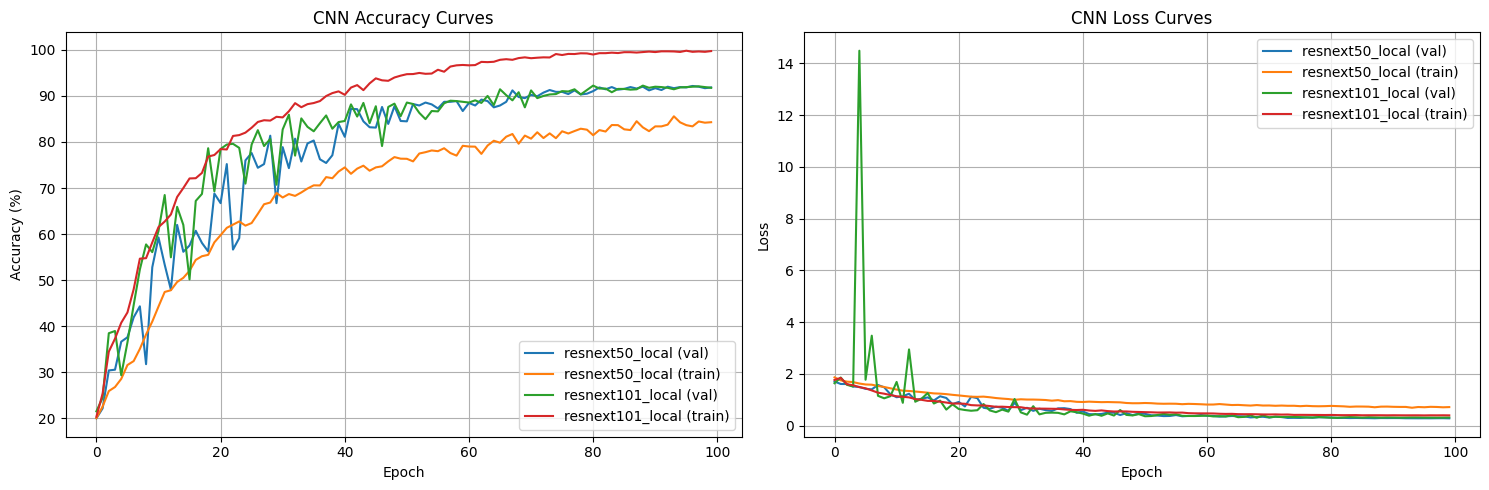

In [15]:
def plot_learning_curves(df, tag):
    tag_df = df[df['tag'] == tag]
    if tag_df.empty:
        print(f"No results for {tag}")
        return
    
    plt.figure(figsize=(15, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_acc'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_acc'], label=f'{name} (train)')
    plt.title(f'{tag} Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # Loss plot
    plt.subplot(1, 2, 2)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_loss'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_loss'], label=f'{name} (train)')
    plt.title(f'{tag} Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(all_metrics, 'CNN')

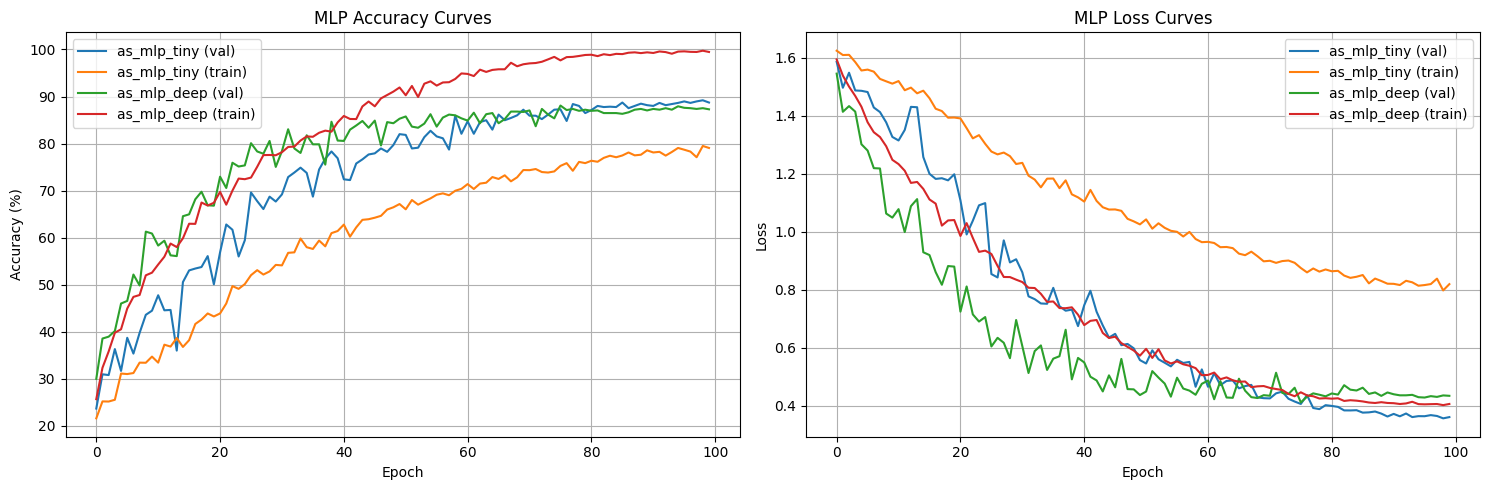

In [16]:
plot_learning_curves(all_metrics, 'MLP')

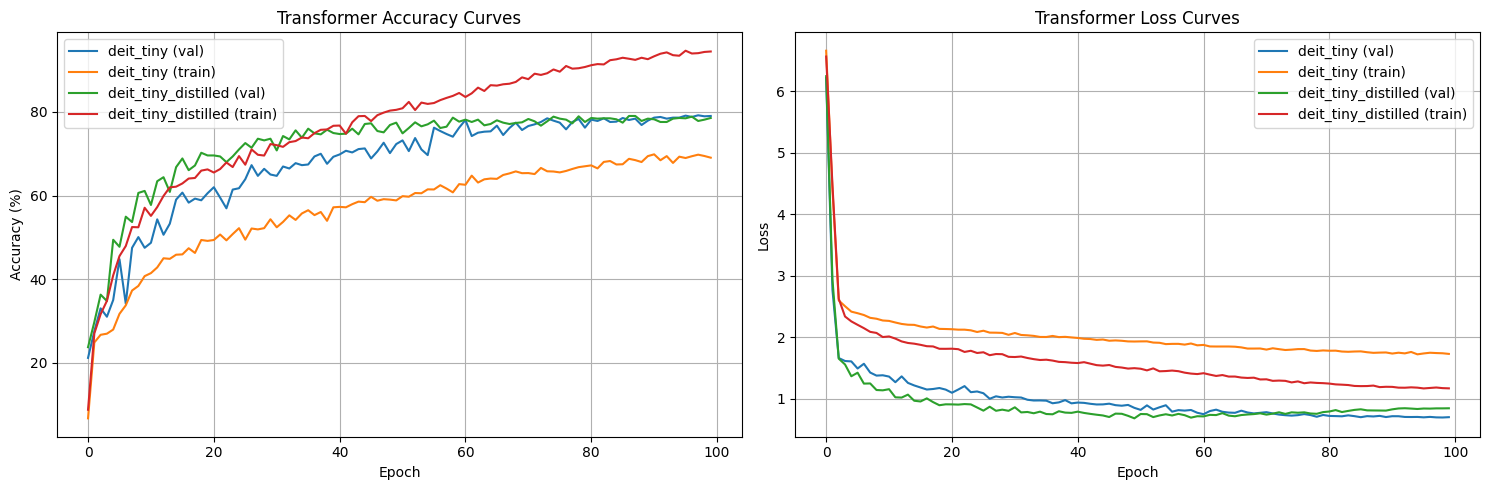

In [17]:
plot_learning_curves(all_metrics, 'Transformer')

## Confusion Matrices Comparison

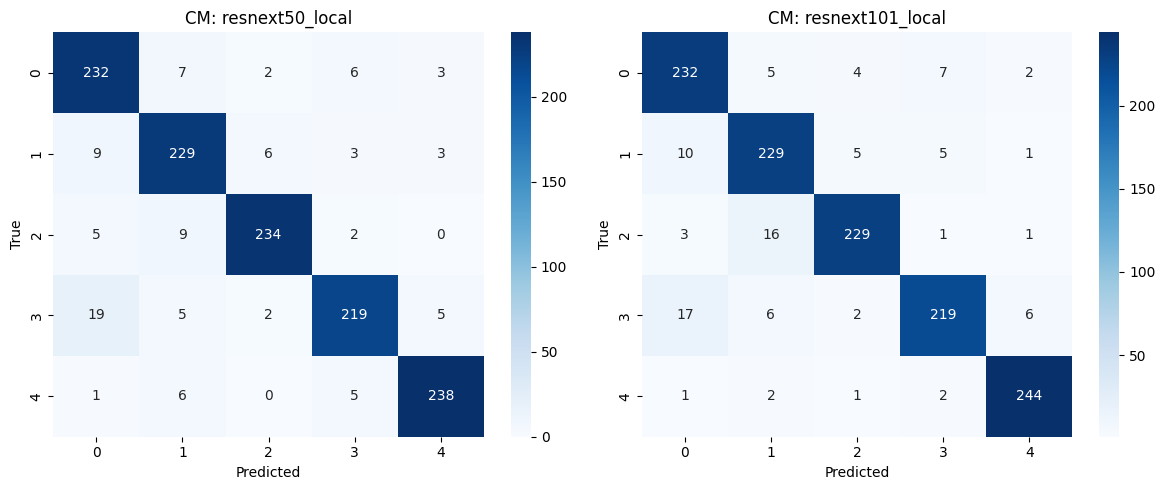

In [18]:
def plot_cms(best_df, cms_dict, tag):
    tag_models = best_df[best_df['tag'] == tag]['model_name'].tolist()
    if not tag_models:
        print(f"No confusion matrices for {tag}")
        return
        
    n_models = len(tag_models)
    plt.figure(figsize=(6*n_models, 5))
    
    for i, name in enumerate(tag_models):
        if name in cms_dict:
            plt.subplot(1, n_models, i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Blues')
            plt.title(f'CM: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
            
    plt.tight_layout()
    plt.show()

plot_cms(best_metrics_df, cms, 'CNN')

## CNN Architecture Confusion Matrix Analysis

### ResNeXt-50 Confusion Matrix Analysis

**Per-class Performance:**

- **beef_tartare**: 232/250 correct (92.8%) (most confused with chicken_quesadilla: 7 cases)
- **chicken_quesadilla**: 229/250 correct (91.6%) (most confused with beef_tartare: 9 cases)
- **pancakes**: 234/250 correct (93.6%) (most confused with chicken_quesadilla: 9 cases)
- **risotto**: 219/250 correct (87.6%) (most confused with beef_tartare: 19 cases)
- **spaghetti_carbonara**: 238/250 correct (95.2%) (most confused with chicken_quesadilla: 6 cases)

**Key Observations:**

- risotto is the lowest performing class at 87.6% accuracy
- Excellent performance on spaghetti_carbonara (95.2%), nearly perfect classification
- Consistent performance across all classes (std dev: 2.6%)
- Overall strong per-class accuracy (92.2% average)

### ResNeXt-101 Confusion Matrix Analysis

**Per-class Performance:**

- **beef_tartare**: 232/250 correct (92.8%) (most confused with risotto: 7 cases)
- **chicken_quesadilla**: 229/250 correct (91.6%) (most confused with beef_tartare: 10 cases)
- **pancakes**: 229/250 correct (91.6%) (most confused with chicken_quesadilla: 16 cases)
- **risotto**: 219/250 correct (87.6%) (most confused with beef_tartare: 17 cases)
- **spaghetti_carbonara**: 244/250 correct (97.6%)

**Key Observations:**

- risotto is the lowest performing class at 87.6% accuracy
- Excellent performance on spaghetti_carbonara (97.6%), nearly perfect classification
- Consistent performance across all classes (std dev: 3.2%)
- Overall strong per-class accuracy (92.2% average)



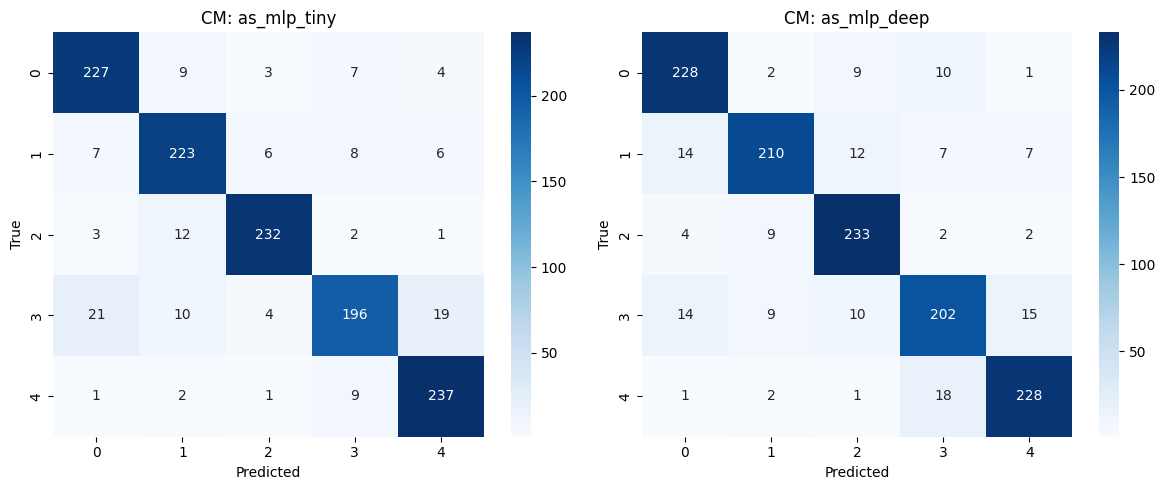

In [19]:
plot_cms(best_metrics_df, cms, 'MLP')

## MLP Architecture Confusion Matrix Analysis

### AS-MLP Tiny Confusion Matrix Analysis

**Per-class Performance:**

- **beef_tartare**: 227/250 correct (90.8%) (most confused with chicken_quesadilla: 9 cases)
- **chicken_quesadilla**: 223/250 correct (89.2%) (most confused with risotto: 8 cases)
- **pancakes**: 232/250 correct (92.8%) (most confused with chicken_quesadilla: 12 cases)
- **risotto**: 196/250 correct (78.4%) (most confused with beef_tartare: 21 cases)
- **spaghetti_carbonara**: 237/250 correct (94.8%) (most confused with risotto: 9 cases)

**Key Observations:**

- risotto is the lowest performing class at 78.4% accuracy
- Strong performance on spaghetti_carbonara (94.8%)
- Moderate variance in class performance (std dev: 5.7%)
- Overall good per-class accuracy (89.2% average)

### AS-MLP Deep Confusion Matrix Analysis

**Per-class Performance:**

- **beef_tartare**: 228/250 correct (91.2%) (most confused with risotto: 10 cases)
- **chicken_quesadilla**: 210/250 correct (84.0%) (most confused with beef_tartare: 14 cases)
- **pancakes**: 233/250 correct (93.2%) (most confused with chicken_quesadilla: 9 cases)
- **risotto**: 202/250 correct (80.8%) (most confused with spaghetti_carbonara: 15 cases)
- **spaghetti_carbonara**: 228/250 correct (91.2%) (most confused with risotto: 18 cases)

**Key Observations:**

- risotto is the lowest performing class at 80.8% accuracy
- Strong performance on pancakes (93.2%)
- Consistent performance across all classes (std dev: 4.8%)
- Overall good per-class accuracy (88.1% average)



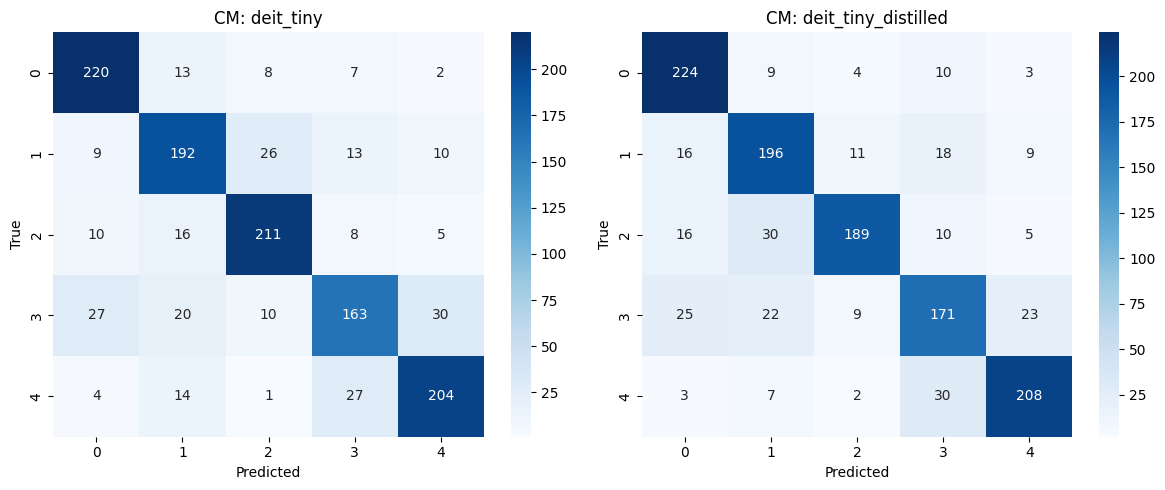

In [20]:
plot_cms(best_metrics_df, cms, 'Transformer')

## Transformer Architecture Confusion Matrix Analysis

### DeiT Tiny Confusion Matrix Analysis

**Per-class Performance:**

- **beef_tartare**: 220/250 correct (88.0%) (most confused with chicken_quesadilla: 13 cases)
- **chicken_quesadilla**: 192/250 correct (76.8%) (most confused with pancakes: 26 cases)
- **pancakes**: 211/250 correct (84.4%) (most confused with chicken_quesadilla: 16 cases)
- **risotto**: 163/250 correct (65.2%) (most confused with spaghetti_carbonara: 30 cases)
- **spaghetti_carbonara**: 204/250 correct (81.6%) (most confused with risotto: 27 cases)

**Key Observations:**

- risotto is the most challenging class (65.2% accuracy), significantly below average
- Best performance on beef_tartare (88.0%)
- Moderate variance in class performance (std dev: 7.9%)
- Per-class accuracy needs improvement (79.2% average)

### DeiT Tiny Distilled Confusion Matrix Analysis

**Per-class Performance:**

- **beef_tartare**: 224/250 correct (89.6%) (most confused with risotto: 10 cases)
- **chicken_quesadilla**: 196/250 correct (78.4%) (most confused with risotto: 18 cases)
- **pancakes**: 189/250 correct (75.6%) (most confused with chicken_quesadilla: 30 cases)
- **risotto**: 171/250 correct (68.4%) (most confused with beef_tartare: 25 cases)
- **spaghetti_carbonara**: 208/250 correct (83.2%) (most confused with risotto: 30 cases)

**Key Observations:**

- risotto is the most challenging class (68.4% accuracy), significantly below average
- Best performance on beef_tartare (89.6%)
- Moderate variance in class performance (std dev: 7.1%)
- Per-class accuracy needs improvement (79.0% average)



## Final Comparison: Best CNN vs Best MLP vs Best Transformer

,tag,model_name,val_acc,val_f1,val_precision,val_recall
80,CNN,resnext101_local,92.24,0.922412,0.923292,0.9224
98,MLP,as_mlp_tiny,89.20,0.891238,0.892231,0.8920
97,Transformer,deit_tiny,79.20,0.790299,0.790486,0.7920


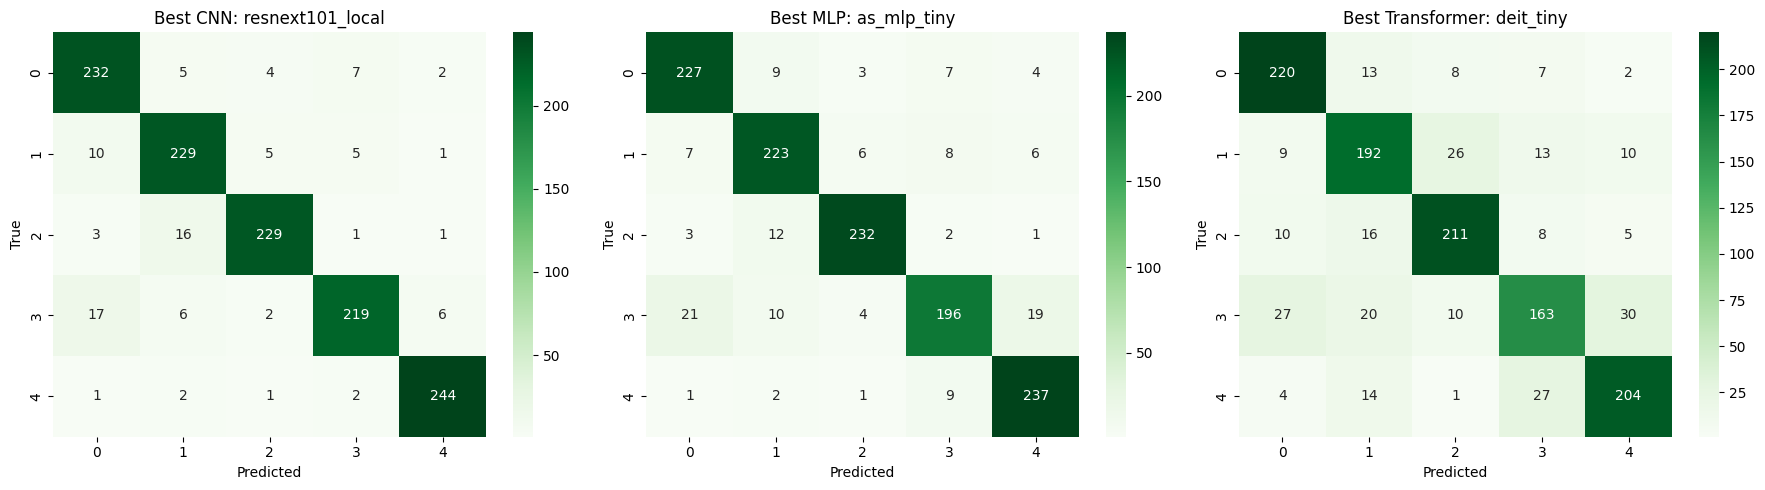

In [21]:
def final_comparison(best_df, cms_dict):
    # Get best model for each tag
    final_best = best_df.sort_values('val_acc', ascending=False).groupby('tag').head(1)
    display(final_best[['tag', 'model_name', 'val_acc', 'val_f1', 'val_precision', 'val_recall']])
    
    # Plot their CMs
    best_models = final_best['model_name'].tolist()
    plt.figure(figsize=(6*len(best_models), 5))
    for i, name in enumerate(best_models):
        if name in cms_dict:
            plt.subplot(1, len(best_models), i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Greens')
            tag = final_best[final_best['model_name'] == name]['tag'].values[0]
            plt.title(f'Best {tag}: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
    plt.tight_layout()
    plt.show()

if best_metrics_df is not None:
    final_comparison(best_metrics_df, cms)

# Model Comparison Summary

Comprehensive comparison of all 6 models trained by BELAL.

## Overall Performance Rankings

| Rank | Model | Val Acc | Train Acc | F1 Score | Precision | Recall |
|------|-------|---------|-----------|----------|-----------|--------|
| 1 | ResNeXt-50 | 91.84% | 84.29% | 0.9185 | 0.9192 | 0.9184 |
| 2 | ResNeXt-101 | 91.76% | 99.73% | 0.9173 | 0.9181 | 0.9176 |
| 3 | AS-MLP Tiny | 88.72% | 79.07% | 0.8865 | 0.8868 | 0.8872 |
| 4 | AS-MLP Deep | 87.28% | 99.47% | 0.8727 | 0.8728 | 0.8728 |
| 5 | DeiT Tiny | 79.04% | 69.07% | 0.7880 | 0.7906 | 0.7904 |
| 6 | DeiT Tiny Distilled | 78.56% | 94.45% | 0.7841 | 0.7851 | 0.7856 |

## Convergence Analysis

| Model | Best Val Acc | Best Epoch | 80% Convergence | Final Val Acc |
|-------|--------------|------------|-----------------|---------------|
| ResNeXt-50 | 92.16% | 96 | Epoch 21 | 91.84% |
| ResNeXt-101 | 92.24% | 80 | Epoch 18 | 91.76% |
| AS-MLP Tiny | 89.20% | 98 | Epoch 31 | 88.72% |
| AS-MLP Deep | 88.08% | 75 | Epoch 20 | 87.28% |
| DeiT Tiny | 79.20% | 97 | Epoch 25 | 79.04% |
| DeiT Tiny Distilled | 79.04% | 87 | Epoch 11 | 78.56% |

**Key Observations:**

- ResNeXt-50 converges fastest (epoch 21), achieving production-ready performance early
- ResNeXt-101 also converges quickly (epoch 18) despite deeper architecture
- DeiT Tiny Distilled has fastest initial convergence (epoch 11) but plateaus at lower accuracy
- AS-MLP Tiny takes longer to converge (epoch 31) but reaches competitive performance
- Most models continue improving until epoch 75-98, suggesting 100 epochs is appropriate

## Overfitting Analysis

| Model | Train Acc | Val Acc | Gap | Assessment |
|-------|-----------|---------|-----|------------|
| DeiT Tiny | 69.07% | 79.04% | -9.97% | Strong regularization (underfit on train) |
| AS-MLP Tiny | 79.07% | 88.72% | -9.65% | Strong regularization (underfit on train) |
| ResNeXt-50 | 84.29% | 91.84% | -7.55% | Strong regularization (underfit on train) |
| ResNeXt-101 | 99.73% | 91.76% | +7.97% | Moderate overfitting |
| AS-MLP Deep | 99.47% | 87.28% | +12.19% | Significant overfitting |
| DeiT Tiny Distilled | 94.45% | 78.56% | +15.89% | Significant overfitting |

**Key Observations:**

- DeiT models show negative gap (train < val), indicating strong regularization during training
- ResNeXt-50 achieves best balance with -7.55% gap, showing excellent generalization
- ResNeXt-101 overfits moderately (+7.97%) despite same regularization as ResNeXt-50
- DeiT Tiny Distilled shows highest overfitting (+15.89%), distillation token may cause train-val disparity
- AS-MLP Deep overfits (+12.19%) despite aggressive regularization (DROP_PATH=0.2, DROP_RATE=0.05)

## Configuration Comparison

| Model | Architecture | Depth | Drop Path | Label Smooth | Weight Decay | Warmup |
|-------|--------------|-------|-----------|--------------|--------------|--------|
| ResNeXt-50 | CNN | 50 layers | 0.15 | 0.1 | 5e-4 | 5 |
| ResNeXt-101 | CNN | 101 layers | 0.15 | 0.1 | 5e-4 | 5 |
| DeiT Tiny | Transformer | 12 layers | 0.1 | 0.1 | 0.05 | 5 |
| DeiT Tiny Distilled | Transformer | 12 layers | 0.1 | 0.1 | 0.05 | 5 |
| AS-MLP Tiny | MLP-Mixer | 12 blocks | 0.1 | 0.1 | 0.05 | 20 |
| AS-MLP Deep | MLP-Mixer | 18 blocks | 0.2 | 0.1 | 0.06 | 25 |

## Architecture Family Analysis

### CNN (ResNeXt)
- Best overall performance (91.76-91.84% validation accuracy)
- Strong inductive biases for spatial features in food images
- ResNeXt-50 preferred over ResNeXt-101 due to less overfitting and similar performance
- Higher regularization (DROP_PATH=0.15) helps with generalization

### Transformer (DeiT)
- Lowest performance (78.56-79.04% validation accuracy)
- Struggles with texture-heavy food classification task
- Distillation token does not provide significant benefit
- May need more data or stronger augmentation to reach CNN performance

### MLP-Mixer (AS-MLP)
- Middle-tier performance (87.28-88.72% validation accuracy)
- AS-MLP Tiny outperforms AS-MLP Deep, suggesting depth hurts without more data
- Longer warmup (20-25 epochs) critical for stability
- Axial shift operation provides reasonable spatial feature extraction

## Final Remark

**Best Model:** ResNeXt-50
- Highest validation accuracy (91.84%)
- Excellent generalization (train 84.29%, val 91.84%)
- Fast convergence (epoch 21 for 80% performance)
- Balanced F1/Precision/Recall scores (all above 0.91)

**Runner-up:** ResNeXt-101
- Nearly identical performance to ResNeXt-50
- Faster convergence but more overfitting

**Best MLP Alternative:** AS-MLP Tiny
- 88.72% validation accuracy
- Good generalization despite MLP architecture
- Outperforms deeper AS-MLP variant

**Avoid:** DeiT models and AS-MLP Deep
- DeiT models underperform on this task (need more data)
- AS-MLP Deep overfits and performs worse than Tiny variant


In [22]:
import shutil
shutil.make_archive('outputs', 'zip', 'outputs')
print("Outputs zipped to outputs.zip")

# print size of outputs.zip
print(f"Size of outputs.zip: {os.path.getsize('outputs.zip') / (1024 * 1024):.2f} MB")

Outputs zipped to outputs.zip
Size of outputs.zip: 0.12 MB


# **SALMA**

## **Training**

In [ ]:
!python main.py --model_to_run densenet121


[2026-04-06 08:42:15,593 densenet121] (main.py 20): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-06 08:42:15,593 densenet121] (main.py 22): INFO Creating model: densenet121
[2026-04-06 08:42:15,797 densenet121] (main.py 58): INFO Early stopping enabled for DenseNet-121
[2026-04-06 08:42:15,797 densenet121] (main.py 64): INFO Start training
[2026-04-06 08:42:33,843 densenet121] (main.py 137): INFO Epoch: [0][0/59] lr 0.000001 loss 1.7650 acc 15.62%
[2026-04-06 08:42:42,757 densenet121] (main.py 137): INFO Epoch: [0][20/59] lr 0.000001 loss 1.7445 acc 16.74%
[2026-04-06 08:42:51,186 densenet121] (main.py 137): INFO Epoch: [0][40/59] lr 0.000001 loss 1.7314 acc 16.88%
[2026-04-06 08:43:29,715 densenet121] (main.py 73): INFO [Epoch 0]: Train Loss: 1.7210, Train Acc: 18.00%, Val Loss: 1.6806, Val Acc: 19.92%, F1: 0.1469, Precision: 0.1580, Recall: 0.1992
[2026-04-06 08:43:29,716 densenet121] (main.py 84): INFO Best performance updated at epoch 0 with accuracy: 19.

In [ ]:
!python main.py --model_to_run convmlp_s


[2026-04-06 10:32:39,945 convmlp_s] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-06 10:32:39,945 convmlp_s] (main.py 23): INFO Creating model: convmlp_s
[2026-04-06 10:32:40,100 convmlp_s] (main.py 63): INFO Start training
[2026-04-06 10:32:50,667 convmlp_s] (main.py 136): INFO Epoch: [0][0/59] lr 0.000001 loss 1.6142 acc 15.62%
[2026-04-06 10:33:02,455 convmlp_s] (main.py 136): INFO Epoch: [0][20/59] lr 0.000001 loss 1.6197 acc 20.24%
[2026-04-06 10:33:15,268 convmlp_s] (main.py 136): INFO Epoch: [0][40/59] lr 0.000001 loss 1.6074 acc 23.36%
[2026-04-06 10:33:42,176 convmlp_s] (main.py 72): INFO [Epoch 0]: Train Loss: 1.5950, Train Acc: 25.57%, Val Loss: 1.5558, Val Acc: 32.00%, F1: 0.2961, Precision: 0.3394, Recall: 0.3200
[2026-04-06 10:33:42,177 convmlp_s] (main.py 83): INFO Best performance updated at epoch 0 with accuracy: 32.00%
[2026-04-06 10:33:42,177 convmlp_s] (main.py 85): INFO Max accuracy: 32.00%
[2026-04-06 10:33:43,572 convmlp_s]

In [ ]:
!python main.py --model_to_run pvt_v2_b0


[2026-04-06 12:30:25,867 pvt_v2_b0] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-06 12:30:25,867 pvt_v2_b0] (main.py 23): INFO Creating model: pvt_v2_b0
[2026-04-06 12:30:26,126 pvt_v2_b0] (main.py 62): INFO Early stopping enabled for PVT-Tiny
[2026-04-06 12:30:26,126 pvt_v2_b0] (main.py 66): INFO Start training
[2026-04-06 12:30:44,339 pvt_v2_b0] (main.py 139): INFO Epoch: [0][0/59] lr 0.000001 loss 1.5738 acc 28.12%
[2026-04-06 12:30:52,129 pvt_v2_b0] (main.py 139): INFO Epoch: [0][20/59] lr 0.000001 loss 1.6284 acc 21.73%
[2026-04-06 12:30:59,872 pvt_v2_b0] (main.py 139): INFO Epoch: [0][40/59] lr 0.000001 loss 1.6043 acc 25.19%
[2026-04-06 12:31:35,396 pvt_v2_b0] (main.py 75): INFO [Epoch 0]: Train Loss: 1.5905, Train Acc: 27.31%, Val Loss: 1.5336, Val Acc: 33.84%, F1: 0.3211, Precision: 0.3217, Recall: 0.3384
[2026-04-06 12:31:35,397 pvt_v2_b0] (main.py 86): INFO Best performance updated at epoch 0 with accuracy: 33.84%
[2026-04-06 12:31:35

## **Results Table**

In [ ]:
import os
import pandas as pd
import numpy as np
from models import get_model_config

def load_results(output_dir='outputs'):
    metrics_dfs = []
    cms = {}
    best_metrics = []

    if not os.path.exists(output_dir):
        return None, None, None

    MY_MODELS = ['densenet121', 'convmlp_s', 'pvt_v2_b0']

    model_names = [
        name for name in MY_MODELS
        if os.path.exists(os.path.join(output_dir, f'{name}_metrics.csv'))
    ]

    for name in model_names:
        # Load metrics
        metrics_path = os.path.join(output_dir, f'{name}_metrics.csv')
        df = pd.read_csv(metrics_path)

        # Get TAG
        config = get_model_config(name)
        tag = config['MODEL']['TAG']

        df['model_name'] = name
        df['tag'] = tag
        metrics_dfs.append(df)

        # Best epoch
        best_epoch_idx = df['val_acc'].idxmax()
        best_row = df.loc[best_epoch_idx].copy()
        best_metrics.append(best_row)

        # Confusion matrix
        cm_path = os.path.join(output_dir, f'{name}_confusion_matrix.npy')
        if os.path.exists(cm_path):
            cms[name] = np.load(cm_path)

    all_metrics = pd.concat(metrics_dfs, ignore_index=True)
    best_metrics_df = pd.DataFrame(best_metrics)

    return all_metrics, best_metrics_df, cms


# Run
all_metrics, best_metrics_df, cms = load_results()

if best_metrics_df is not None:
    display(best_metrics_df.sort_values(by='val_acc', ascending=False))

,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,model_name,tag
10,10,0.422938,99.546667,0.165720,97.44,0.974414,0.974654,0.9744,densenet121,CNN
3,3,0.509271,94.693333,0.209647,95.76,0.957701,0.959041,0.9576,pvt_v2_b0,TRANSFORMER
97,97,0.623791,92.160000,0.362831,90.24,0.902674,0.903346,0.9024,convmlp_s,MLP


## **learning Curves**

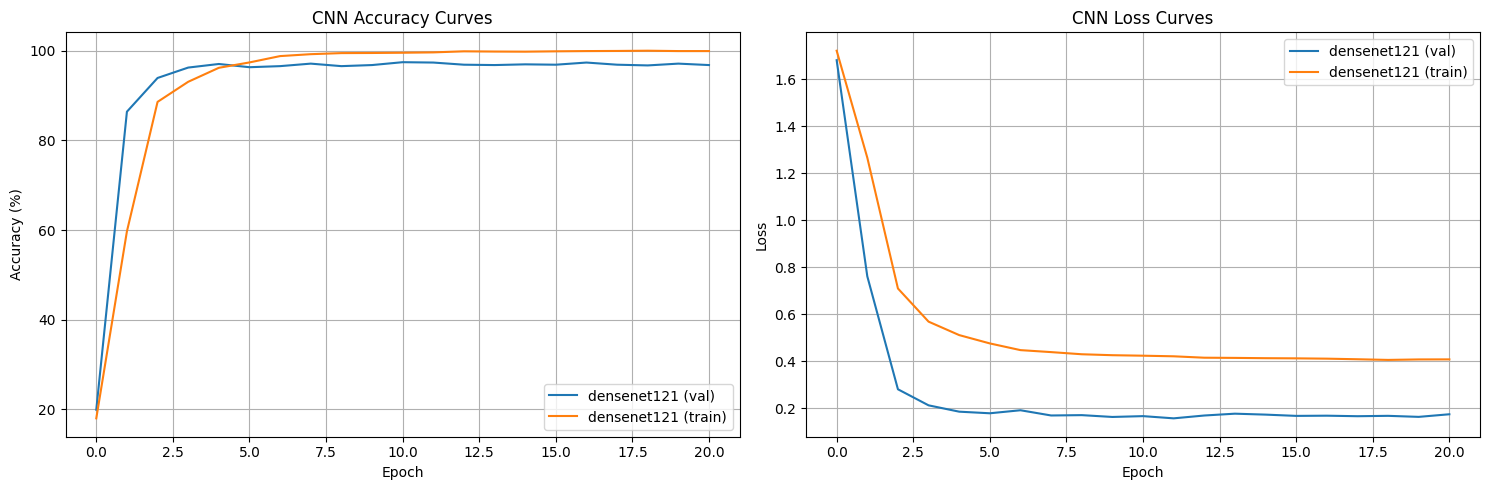

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(df, tag):
    tag_df = df[df['tag'] == tag]
    if tag_df.empty:
        print(f"No results for {tag}")
        return

    plt.figure(figsize=(15, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_acc'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_acc'], label=f'{name} (train)')
    plt.title(f'{tag} Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_loss'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_loss'], label=f'{name} (train)')
    plt.title(f'{tag} Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(all_metrics, 'CNN')

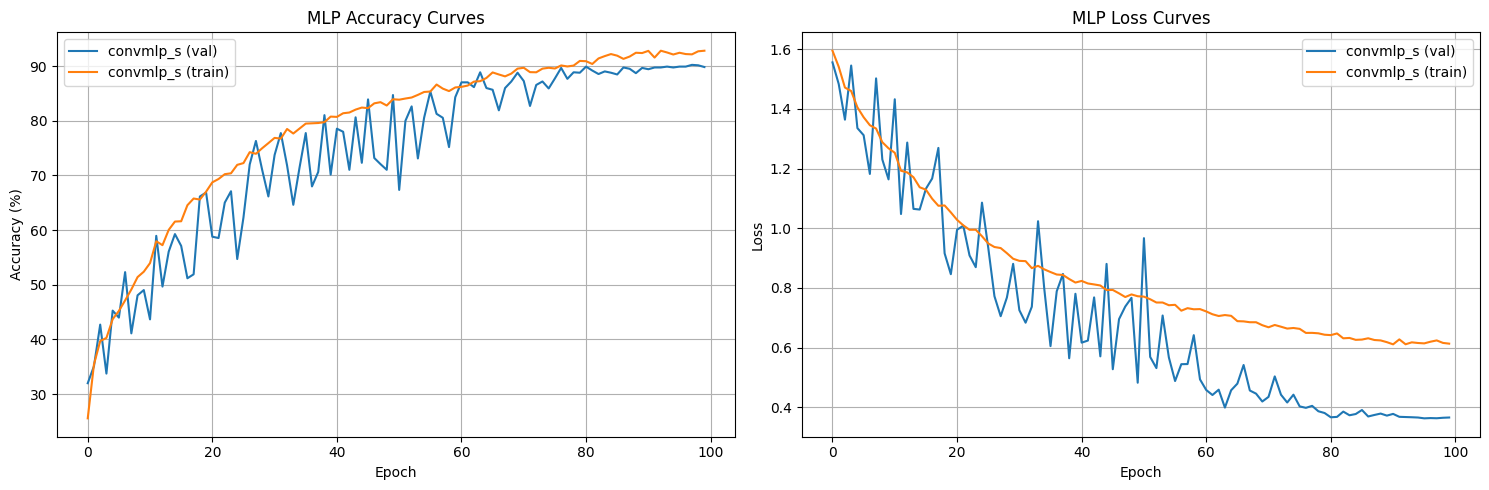

In [ ]:
plot_learning_curves(all_metrics, 'MLP')

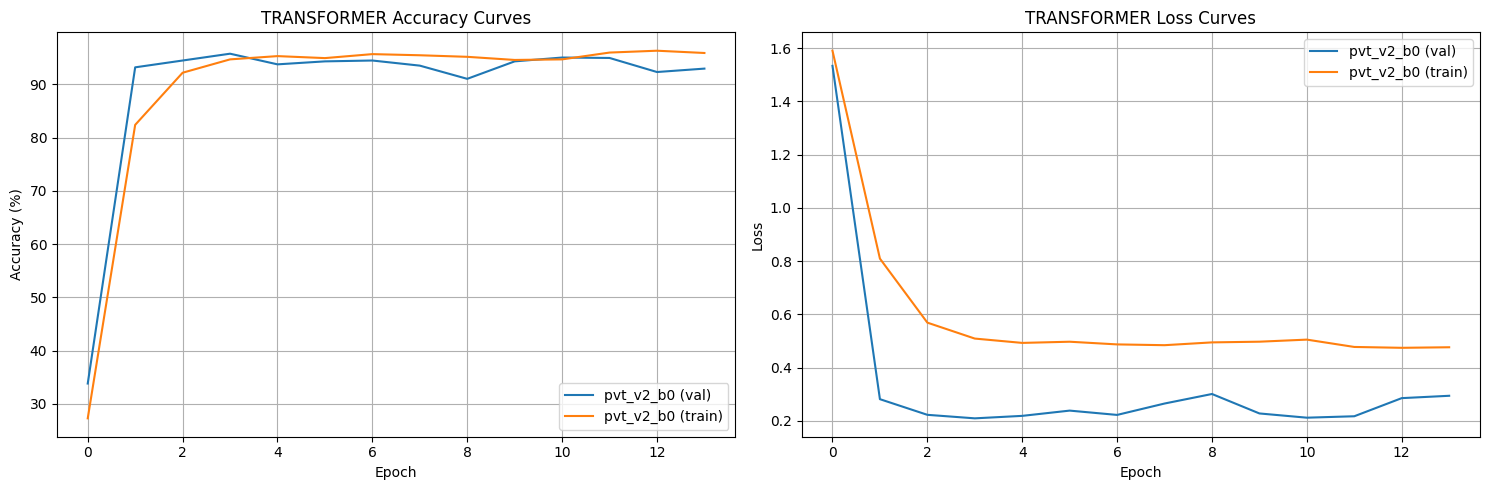

In [ ]:
plot_learning_curves(all_metrics, 'TRANSFORMER')

## **Confusion Matrices**

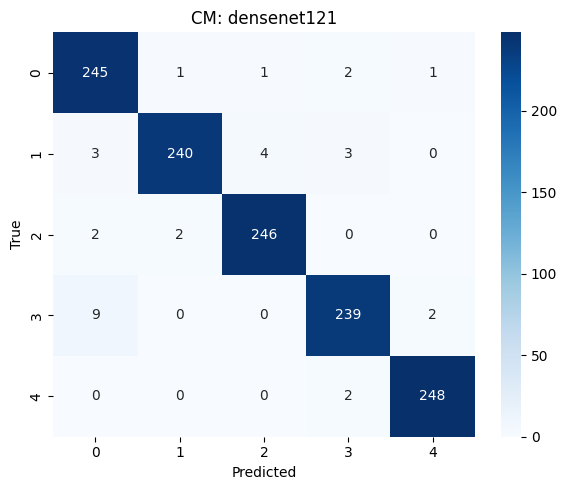

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cms(best_df, cms_dict, tag):
    tag_models = best_df[best_df['tag'] == tag]['model_name'].tolist()
    if not tag_models:
        print(f"No confusion matrices for {tag}")
        return

    n_models = len(tag_models)
    plt.figure(figsize=(6*n_models, 5))

    for i, name in enumerate(tag_models):
        if name in cms_dict:
            plt.subplot(1, n_models, i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Blues')
            plt.title(f'CM: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')

    plt.tight_layout()
    plt.show()

plot_cms(best_metrics_df, cms, 'CNN')

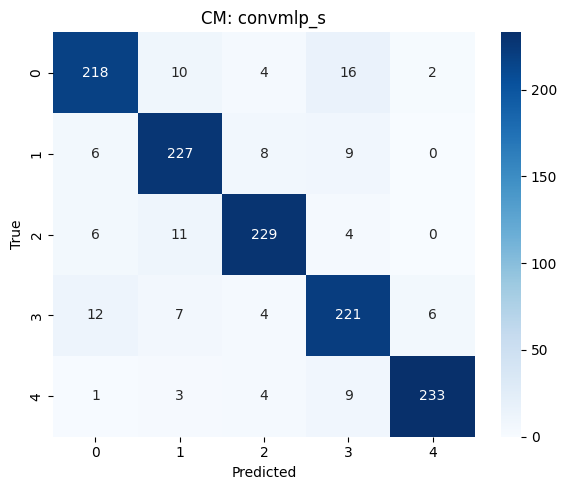

In [ ]:
plot_cms(best_metrics_df, cms, 'MLP')

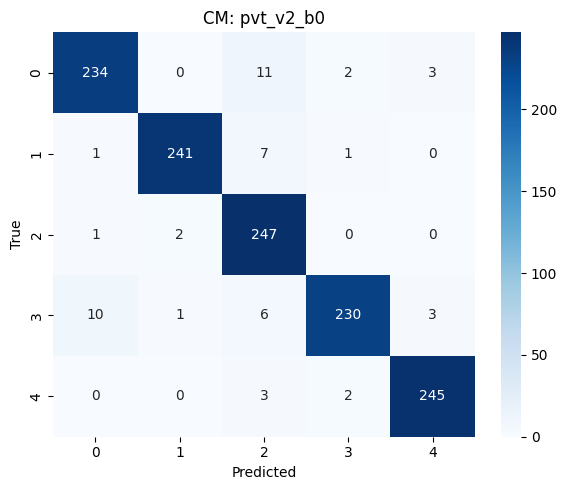

In [ ]:
plot_cms(best_metrics_df, cms, 'TRANSFORMER')

,tag,model_name,val_acc,val_f1,val_precision,val_recall
10,CNN,densenet121,97.44,0.974414,0.974654,0.9744
3,TRANSFORMER,pvt_v2_b0,95.76,0.957701,0.959041,0.9576
97,MLP,convmlp_s,90.24,0.902674,0.903346,0.9024


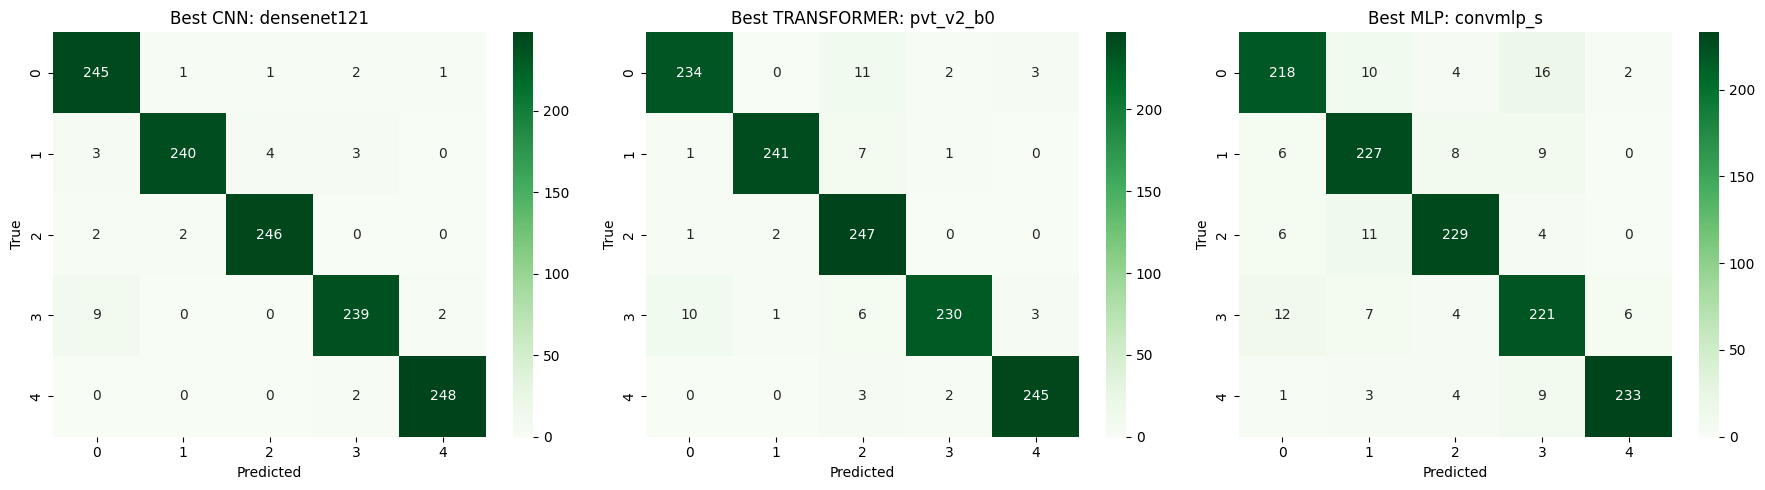

In [ ]:
def final_comparison(best_df, cms_dict):
    # Get best model for each tag
    final_best = best_df.sort_values('val_acc', ascending=False).groupby('tag').head(1)
    display(final_best[['tag', 'model_name', 'val_acc', 'val_f1', 'val_precision', 'val_recall']])

    # Plot their CMs
    best_models = final_best['model_name'].tolist()
    plt.figure(figsize=(6*len(best_models), 5))
    for i, name in enumerate(best_models):
        if name in cms_dict:
            plt.subplot(1, len(best_models), i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Greens')
            tag = final_best[final_best['model_name'] == name]['tag'].values[0]
            plt.title(f'Best {tag}: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
    plt.tight_layout()
    plt.show()

if best_metrics_df is not None:
    final_comparison(best_metrics_df, cms)

# **Habiba**

In [ ]:
!python main.py --model_to_run resnet18

[2026-04-07 15:01:50,446 resnet18] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-07 15:01:50,446 resnet18] (main.py 23): INFO Creating model: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 172MB/s]
[2026-04-07 15:01:51,077 resnet18] (main.py 67): INFO Start training
[2026-04-07 15:02:06,679 resnet18] (main.py 140): INFO Epoch: [0][0/59] lr 0.000001 loss 1.7053 acc 28.12%
[2026-04-07 15:02:13,347 resnet18] (main.py 140): INFO Epoch: [0][20/59] lr 0.000001 loss 1.7686 acc 18.97%
[2026-04-07 15:02:22,312 resnet18] (main.py 140): INFO Epoch: [0][40/59] lr 0.000001 loss 1.7461 acc 19.78%
[2026-04-07 15:02:44,135 resnet18] (main.py 76): INFO [Epoch 0]: Train Loss: 1.7251, Train Acc: 20.69%, Val Loss: 1.6353, Val Acc: 23.84%, F1: 0.1899, Precision: 0.2248, Recall: 0.2384
[2026-04-07 15:02:44,135 resnet18] (main.py 87): INFO Best 

In [ ]:
!python main.py --model_to_run gmlp_tiny

[2026-04-07 16:02:08,768 gmlp_tiny] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-07 16:02:08,768 gmlp_tiny] (main.py 23): INFO Creating model: gmlp_tiny
[2026-04-07 16:02:08,923 gmlp_tiny] (main.py 67): INFO Start training
[2026-04-07 16:02:12,896 gmlp_tiny] (main.py 140): INFO Epoch: [0][0/59] lr 0.000001 loss 1.6338 acc 17.19%
[2026-04-07 16:02:19,483 gmlp_tiny] (main.py 140): INFO Epoch: [0][20/59] lr 0.000001 loss 1.6518 acc 17.19%
[2026-04-07 16:02:28,911 gmlp_tiny] (main.py 140): INFO Epoch: [0][40/59] lr 0.000001 loss 1.6350 acc 20.35%
[2026-04-07 16:02:43,378 gmlp_tiny] (main.py 76): INFO [Epoch 0]: Train Loss: 1.6327, Train Acc: 20.88%, Val Loss: 1.6007, Val Acc: 27.84%, F1: 0.1913, Precision: 0.2156, Recall: 0.2784
[2026-04-07 16:02:43,378 gmlp_tiny] (main.py 87): INFO Best performance updated at epoch 0 with accuracy: 27.84%
[2026-04-07 16:02:43,378 gmlp_tiny] (main.py 89): INFO Max accuracy: 27.84%
[2026-04-07 16:02:44,446 gmlp_tiny]

In [ ]:
!python main.py --model_to_run vit_base

[2026-04-07 16:30:42,754 vit_base] (main.py 21): INFO Dataset loaded: 3750 train images, 1250 validation images
[2026-04-07 16:30:42,754 vit_base] (main.py 23): INFO Creating model: vit_base
[2026-04-07 16:30:43,901 vit_base] (main.py 67): INFO Start training
[2026-04-07 16:30:45,984 vit_base] (main.py 140): INFO Epoch: [0][0/118] lr 0.000001 loss 1.7854 acc 12.50%
[2026-04-07 16:30:53,346 vit_base] (main.py 140): INFO Epoch: [0][20/118] lr 0.000001 loss 1.6374 acc 23.81%
[2026-04-07 16:31:00,896 vit_base] (main.py 140): INFO Epoch: [0][40/118] lr 0.000001 loss 1.6010 acc 27.29%
[2026-04-07 16:31:08,694 vit_base] (main.py 140): INFO Epoch: [0][60/118] lr 0.000001 loss 1.5923 acc 26.84%
[2026-04-07 16:31:16,693 vit_base] (main.py 140): INFO Epoch: [0][80/118] lr 0.000001 loss 1.5803 acc 27.85%
[2026-04-07 16:31:24,833 vit_base] (main.py 140): INFO Epoch: [0][100/118] lr 0.000001 loss 1.5713 acc 28.53%
[2026-04-07 16:31:51,984 vit_base] (main.py 76): INFO [Epoch 0]: Train Loss: 1.5626, T

In [ ]:
import os
import pandas as pd
import numpy as np
from models import get_model_config

def load_results(output_dir='outputs'):
    metrics_dfs = []
    cms = {}
    best_metrics = []

    if not os.path.exists(output_dir):
        return None, None, None

    MY_MODELS = ['resnet18', 'gmlp_tiny', 'vit_base']

    model_names = [
        name for name in MY_MODELS
        if os.path.exists(os.path.join(output_dir, f'{name}_metrics.csv'))
    ]

    for name in model_names:
        # Load metrics
        metrics_path = os.path.join(output_dir, f'{name}_metrics.csv')
        df = pd.read_csv(metrics_path)

        # Get TAG
        config = get_model_config(name)
        tag = config['MODEL']['TAG']

        df['model_name'] = name
        df['tag'] = tag
        metrics_dfs.append(df)

        # Best epoch
        best_epoch_idx = df['val_acc'].idxmax()
        best_row = df.loc[best_epoch_idx].copy()
        best_metrics.append(best_row)

        # Confusion matrix
        cm_path = os.path.join(output_dir, f'{name}_confusion_matrix.npy')
        if os.path.exists(cm_path):
            cms[name] = np.load(cm_path)

    all_metrics = pd.concat(metrics_dfs, ignore_index=True)
    best_metrics_df = pd.DataFrame(best_metrics)

    return all_metrics, best_metrics_df, cms


# Run
all_metrics, best_metrics_df, cms = load_results()

if best_metrics_df is not None:
    display(best_metrics_df.sort_values(by='val_acc', ascending=False))

,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,model_name,tag
95,95,0.392131,100.000000,0.177555,96.88,0.968861,0.969084,0.9688,resnet18,CNN
37,37,0.610508,90.533333,1.058962,61.76,0.616249,0.621690,0.6176,gmlp_tiny,MLP
48,48,1.299828,50.240000,1.166785,54.80,0.543289,0.544059,0.5480,vit_base,TRANSFORMER


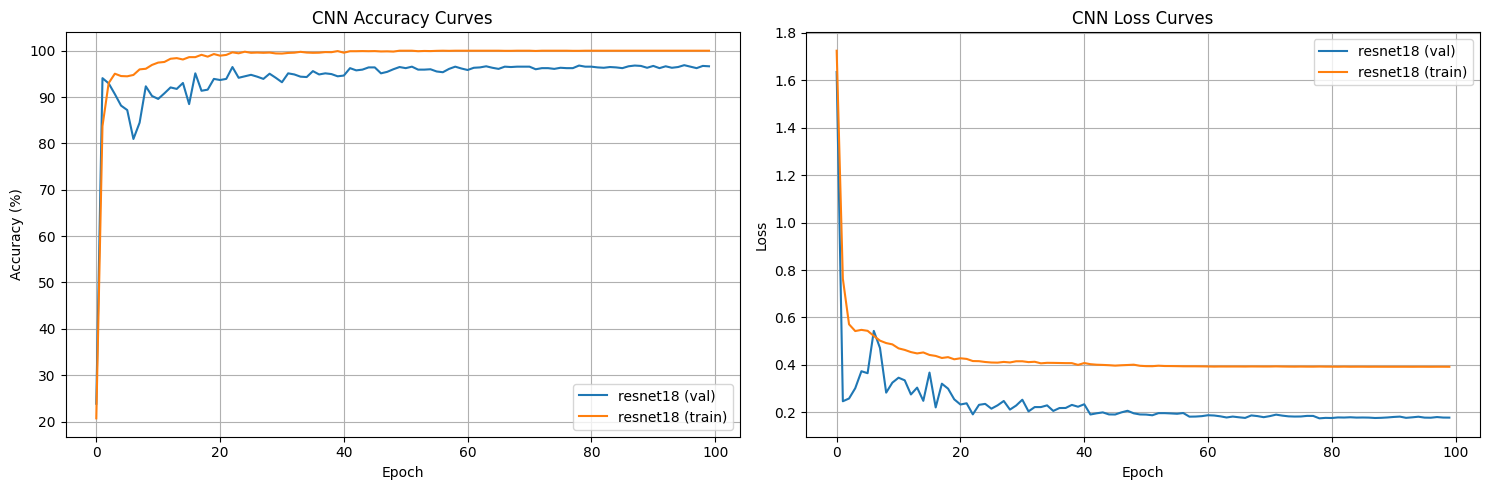

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(df, tag):
    tag_df = df[df['tag'] == tag]
    if tag_df.empty:
        print(f"No results for {tag}")
        return

    plt.figure(figsize=(15, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_acc'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_acc'], label=f'{name} (train)')
    plt.title(f'{tag} Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    for name in tag_df['model_name'].unique():
        model_df = tag_df[tag_df['model_name'] == name]
        plt.plot(model_df['epoch'], model_df['val_loss'], label=f'{name} (val)')
        plt.plot(model_df['epoch'], model_df['train_loss'], label=f'{name} (train)')
    plt.title(f'{tag} Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(all_metrics, 'CNN')

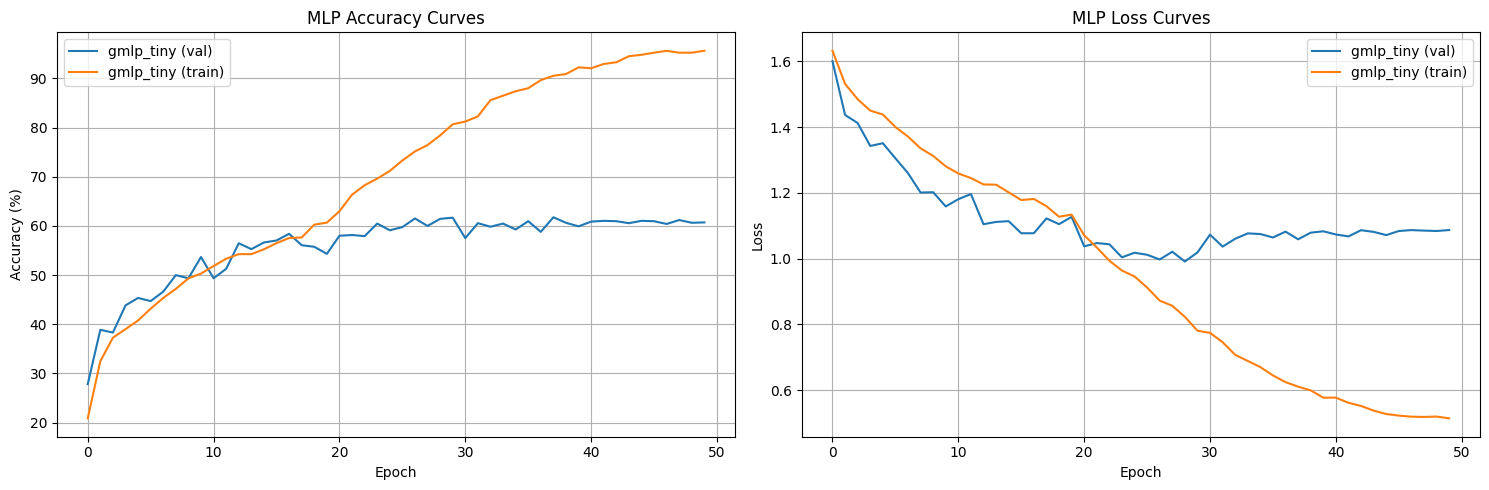

In [ ]:
plot_learning_curves(all_metrics, 'MLP')

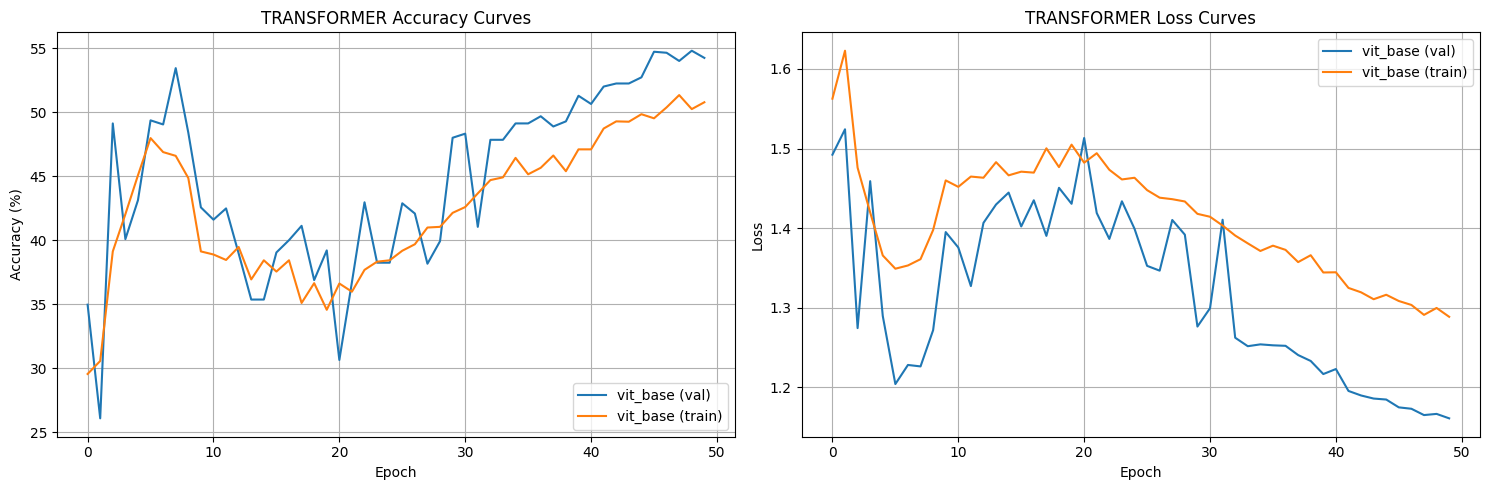

In [ ]:
plot_learning_curves(all_metrics, 'TRANSFORMER')

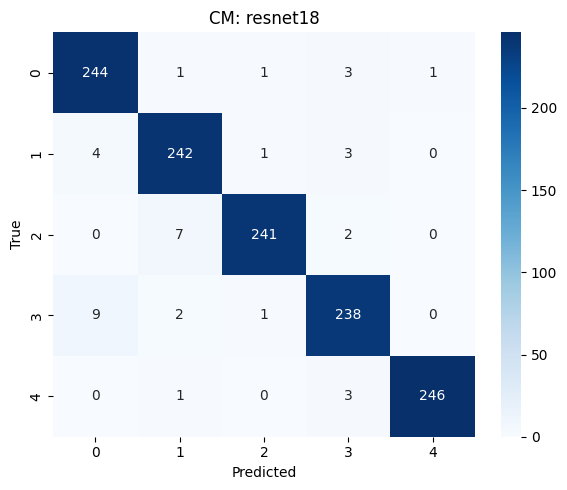

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cms(best_df, cms_dict, tag):
    tag_models = best_df[best_df['tag'] == tag]['model_name'].tolist()
    if not tag_models:
        print(f"No confusion matrices for {tag}")
        return

    n_models = len(tag_models)
    plt.figure(figsize=(6*n_models, 5))

    for i, name in enumerate(tag_models):
        if name in cms_dict:
            plt.subplot(1, n_models, i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Blues')
            plt.title(f'CM: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')

    plt.tight_layout()
    plt.show()

plot_cms(best_metrics_df, cms, 'CNN')

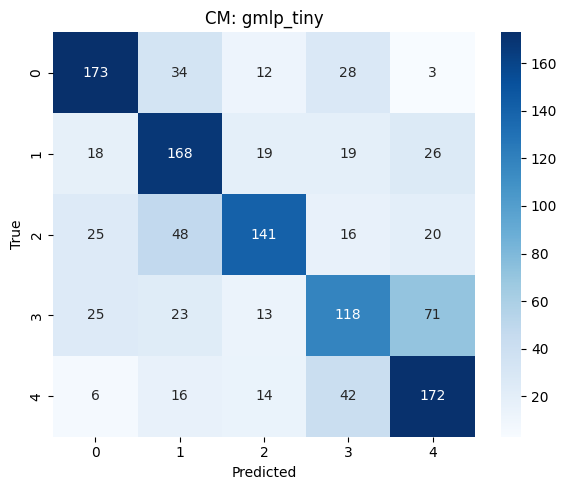

In [ ]:
plot_cms(best_metrics_df, cms, 'MLP')

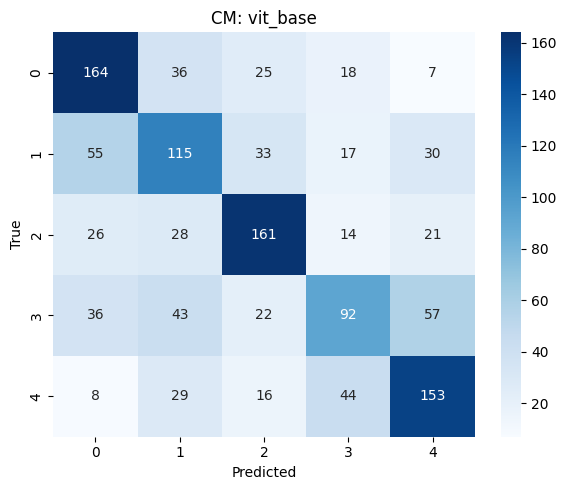

In [ ]:
plot_cms(best_metrics_df, cms, 'TRANSFORMER')

,tag,model_name,val_acc,val_f1,val_precision,val_recall
95,CNN,resnet18,96.88,0.968861,0.969084,0.9688
37,MLP,gmlp_tiny,61.76,0.616249,0.621690,0.6176
48,TRANSFORMER,vit_base,54.80,0.543289,0.544059,0.5480


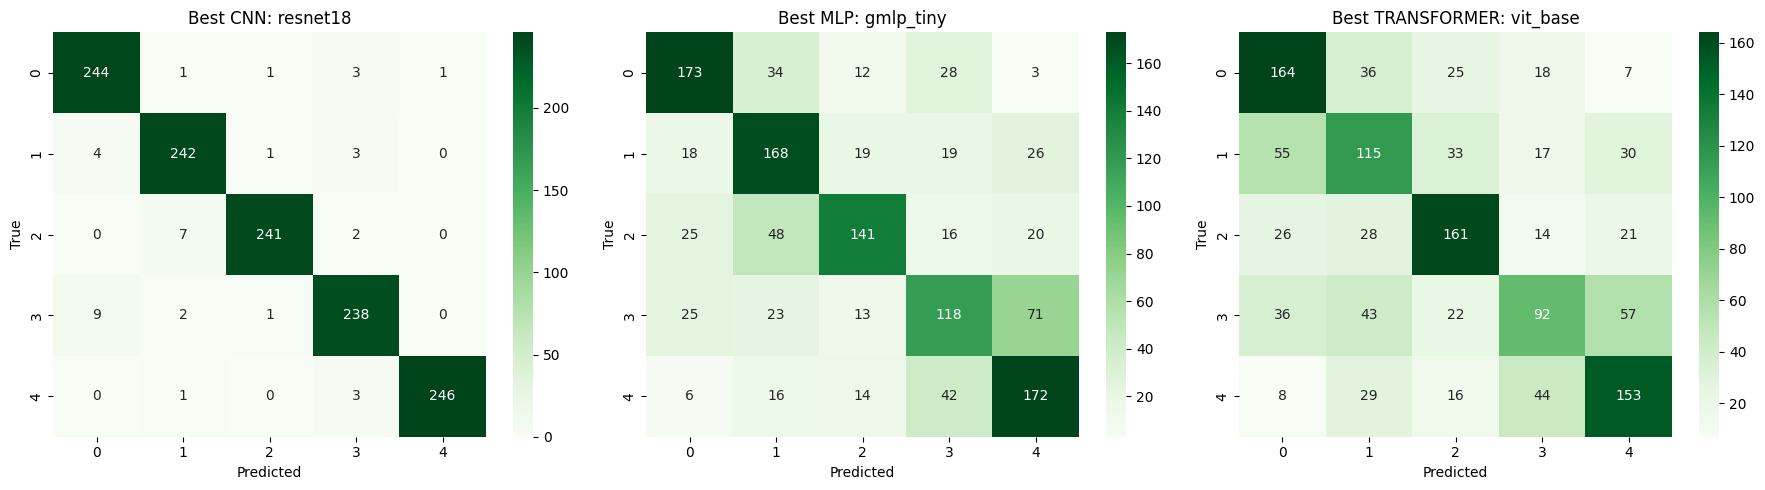

In [ ]:
def final_comparison(best_df, cms_dict):
    # Get best model for each tag
    final_best = best_df.sort_values('val_acc', ascending=False).groupby('tag').head(1)
    display(final_best[['tag', 'model_name', 'val_acc', 'val_f1', 'val_precision', 'val_recall']])

    # Plot their CMs
    best_models = final_best['model_name'].tolist()
    plt.figure(figsize=(6*len(best_models), 5))
    for i, name in enumerate(best_models):
        if name in cms_dict:
            plt.subplot(1, len(best_models), i+1)
            sns.heatmap(cms_dict[name], annot=True, fmt='d', cmap='Greens')
            tag = final_best[final_best['model_name'] == name]['tag'].values[0]
            plt.title(f'Best {tag}: {name}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
    plt.tight_layout()
    plt.show()

if best_metrics_df is not None:
    final_comparison(best_metrics_df, cms)